# 1. Import Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import os
from tensorflow.keras.preprocessing import image
import shutil
import random
import cv2

# 2. Load Dataset


#### I got this data from the Universe website
URL: 'https://universe.roboflow.com/inatel/pneumonia-classification-imrcv'

In [2]:
train_path = 'dataset/train'
valid_path = 'dataset/valid'
test_path = 'dataset/test'

# 3. Dataset Exploration 

#### In this step, we identify the number of images in each split, including the normal and infected images. I also display examples of both infected and normal images


--- Folder: train ---
Number of NORMAL images: 1139
Number of PNEUMONIA_BACTERIA images: 2136
Number of PNEUMONIA_VIRAL images: 1138

--- Folder: valid ---
Number of NORMAL images: 208
Number of PNEUMONIA_BACTERIA images: 384
Number of PNEUMONIA_VIRAL images: 200

--- Folder: test ---
Number of NORMAL images: 231
Number of PNEUMONIA_BACTERIA images: 240
Number of PNEUMONIA_VIRAL images: 147



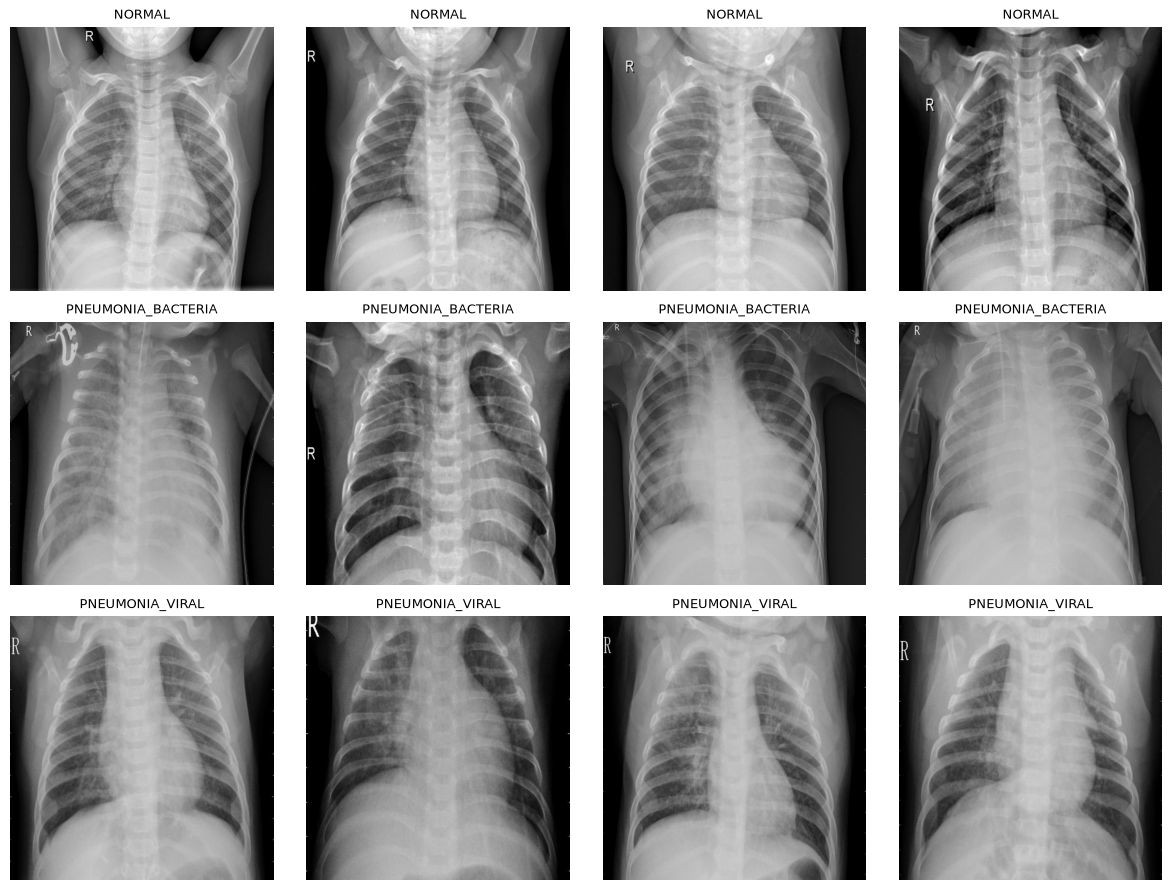

In [3]:
BASE_DATASET_PATH = 'dataset'

def explore_dataset(base_path, folder_name):
    print(f"--- Folder: {folder_name} ---")
    folder_path = os.path.join(base_path, folder_name)
    
    if not os.path.exists(folder_path):
        print(f"Folder {folder_name} does not exist.\n")
        return

    categories = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]
    
    for category in sorted(categories):
        path = os.path.join(folder_path, category)
        count = len(os.listdir(path))
        print(f"Number of {category} images: {count}")
    print()


def rebalance_validation_set(base_path, split_ratio=0.15):
    train_dir = os.path.join(base_path, 'train')
    valid_dir = os.path.join(base_path, 'valid') 
    
    categories = ['NORMAL', 'PNEUMONIA_BACTERIA', 'PNEUMONIA_VIRAL']
    
    wrong_valid_path = os.path.join(valid_dir, 'PNEUMONIA_BACTERIAL')
    correct_valid_path = os.path.join(valid_dir, 'PNEUMONIA_BACTERIA')
    if os.path.exists(wrong_valid_path):
        os.rename(wrong_valid_path, correct_valid_path)

    for cat in categories:
        src_cat_dir = os.path.join(train_dir, cat)
        dest_cat_dir = os.path.join(valid_dir, cat)
        
        os.makedirs(dest_cat_dir, exist_ok=True)
        
        if os.path.exists(src_cat_dir):
            images = os.listdir(src_cat_dir)
            num_to_move = int(len(images) * split_ratio)
            
            random.seed(42)
            images_to_move = random.sample(images, num_to_move)
            
            for img_name in images_to_move:
                src_path = os.path.join(src_cat_dir, img_name)
                dest_path = os.path.join(dest_cat_dir, img_name)
                shutil.move(src_path, dest_path)


def plot_sample_images(base_path):
    categories = ['NORMAL', 'PNEUMONIA_BACTERIA', 'PNEUMONIA_VIRAL']
    
    fig, axes = plt.subplots(len(categories), 4, figsize=(12, 9))
    
    for row, category in enumerate(categories):
        folder_path = os.path.join(base_path, 'train', category)
        
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
            
        image_files = sorted(os.listdir(folder_path))[:4] 
        
        for col, img_name in enumerate(image_files):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[row, col].imshow(img)
                axes[row, col].set_title(f"{category}", fontsize=9)
            
            axes[row, col].axis('off')
            
    plt.tight_layout()
    plt.show()

explore_dataset(BASE_DATASET_PATH, 'train')
explore_dataset(BASE_DATASET_PATH, 'valid')
explore_dataset(BASE_DATASET_PATH, 'test')

plot_sample_images(BASE_DATASET_PATH)

# 4. Data Visualization

#### I displayed the number of normal and infected in each split, along with the percentages of infected and normal images in the training split


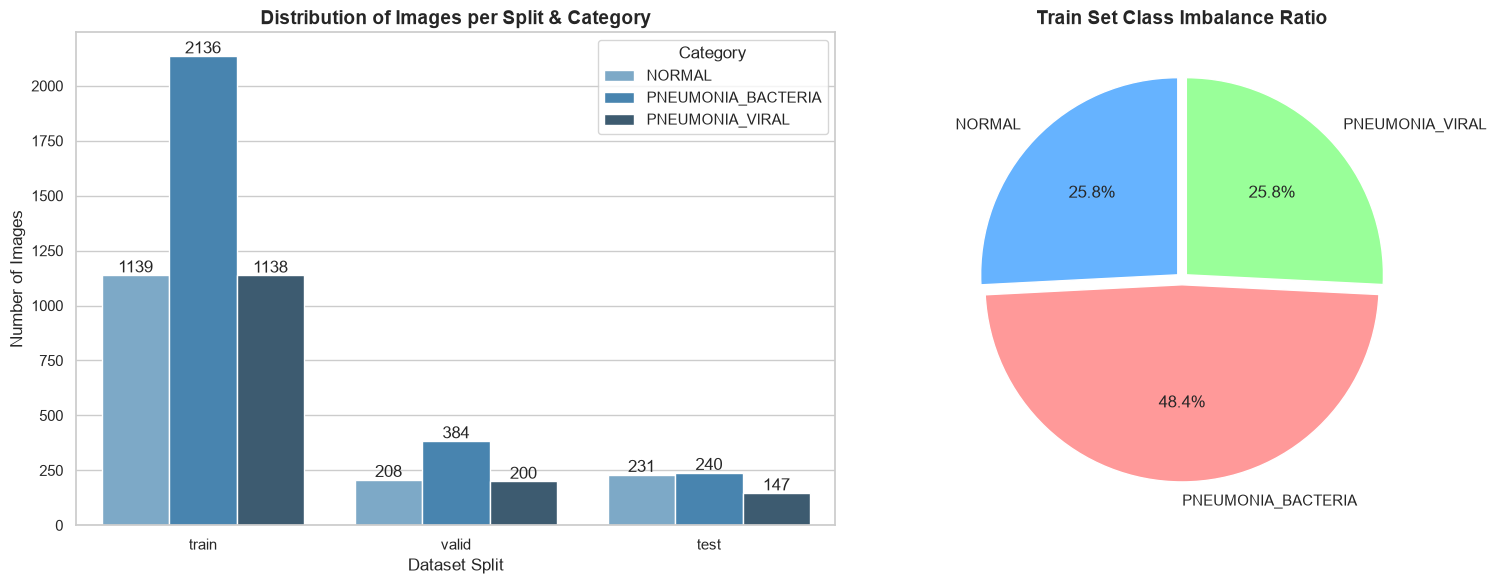

In [4]:
BASE_DATASET_PATH = 'dataset'

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

data_counts = []

categories = ['NORMAL', 'PNEUMONIA_BACTERIA', 'PNEUMONIA_VIRAL']

for split in ['train', 'valid', 'test']:  
    for category in categories:
        path = os.path.join(BASE_DATASET_PATH, split, category)
        
        if os.path.exists(path):
            count = len(os.listdir(path))
            
            data_counts.append({
                'Split': split, 
                'Category': category, 
                'Count': count
            })

df = pd.DataFrame(data_counts)

sns.barplot(
    data=df, 
    x='Split', 
    y='Count', 
    hue='Category', 
    ax=axes[0], 
    palette='Blues_d'
)

axes[0].set_title('Distribution of Images per Split & Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dataset Split', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)

for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(
            f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', 
            va='center', 
            xytext=(0, 5), 
            textcoords='offset points'
        )

train_df = df[df['Split'] == 'train']

colors = ['#66b3ff', '#ff9999', '#99ff99']
explode = (0.03, 0.03, 0.03)

axes[1].pie(
    train_df['Count'], 
    labels=train_df['Category'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors, 
    explode=explode
)

axes[1].set_title('Train Set Class Imbalance Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Data Preprocessing


#### In this step, I rescaled all the data and applied Data Augmentation to the training data


In [5]:
train_path = 'dataset/train'
valid_path = 'dataset/valid' 
test_path  = 'dataset/test'

train_datagen = ImageDataGenerator(
    rescale=1/255,        
    rotation_range=15,    
    zoom_range=0.1,   
    width_shift_range=0.1, 
    height_shift_range=0.1,   
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1/255)
test_datagen = ImageDataGenerator(rescale=1/255)

data_train = train_datagen.flow_from_directory(
    train_path, 
    color_mode='grayscale',
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',  
    shuffle=True
)

data_valid = valid_datagen.flow_from_directory(
    valid_path, 
    color_mode='grayscale',
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',  
    shuffle=False
)

data_test = test_datagen.flow_from_directory(
    test_path, 
    color_mode='grayscale',
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical', 
    shuffle=False  
)

Found 4413 images belonging to 3 classes.
Found 792 images belonging to 3 classes.
Found 618 images belonging to 3 classes.


# 6. CNN Architecture


#### In this step, I built a Convolutional Neural Network model for image classification

-The model consists of three convolutional layers

After the convolutional layers, I used a Flatten layer to convert the extracted feature maps into a one-dimensional vector. Then, I added a Dropout layer with a rate of 0.3 to reduce overfitting

-The model contains two fully connected Dense layers with 256 and 128 neurons

In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),  
      
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()

c:\Users\Hosam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,266,435 (50.61 MB)

 Trainable params: 13,266,435 (50.61 MB)

 Non-trainable params: 0 (0.00 B)

# 7. Model Compilation

#### I used Early Stopping to prevent overfitting by monitoring the validation loss

#### then compiled the model using the Adam optimizer, Binary Cross-Entropy loss, and Accuracy as the evaluation metric

In [9]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(data_train.classes),
    y=data_train.classes
)
class_weight_dict = dict(enumerate(class_weights))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 8. Model Training

#### I trained the model for up to 15 epochs with Early Stopping enabled to stop training when the validation loss stopped improving

In [ ]:
history = model.fit(
    data_train,
    epochs=15,
    validation_data=data_valid,
    callbacks=[early_stopping],
    class_weight=class_weight_dict
)

In [7]:
model = load_model('pneumonia_detection_model.keras')

# 9. Model Evaluation

#### I evaluated the model on the test dataset by generating predictions and converting them into binary classes using a 0.5 threshold,

#### then used the Classification Report to measure the model’s performance and the Confusion Matrix to analyze the correct and incorrect predictions

In [10]:
predictions = model.predict(data_test)

y_pred = np.argmax(predictions, axis=1)
y_true = data_test.classes

target_names = list(data_test.class_indices.keys())
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names))

test_loss, test_acc = model.evaluate(data_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step

--- Classification Report ---
                    precision    recall  f1-score   support

            NORMAL       0.96      0.79      0.87       231
PNEUMONIA_BACTERIA       0.82      0.96      0.88       240
   PNEUMONIA_VIRAL       0.78      0.78      0.78       147

          accuracy                           0.85       618
         macro avg       0.85      0.84      0.84       618
      weighted avg       0.86      0.85      0.85       618

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.8544 - loss: 0.5114
Test Loss: 0.5114
Test Accuracy: 85.44%


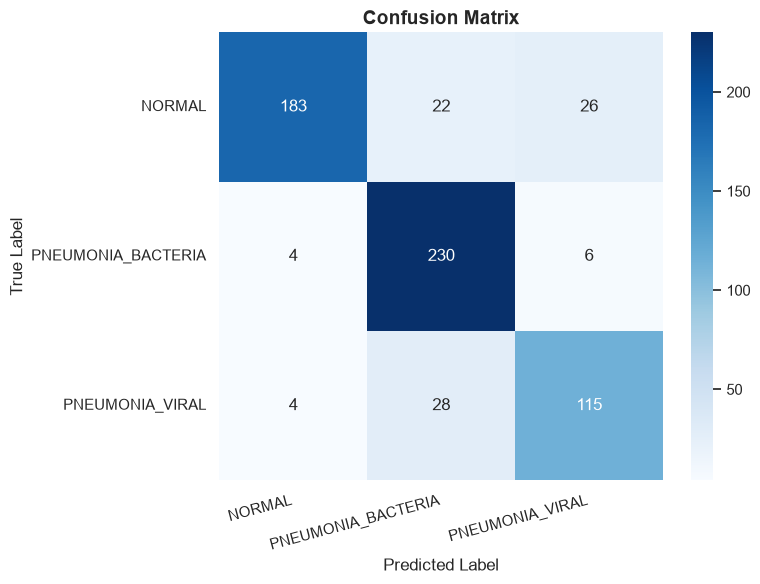

In [22]:
cm = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(8, 6)) 

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=target_names, 
    yticklabels=target_names
)

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

# 10. Accuracy and Loss Curves

#### I plotted the Training and Validation Accuracy and Loss curves to monitor the model’s performance during training and compare how well it generalizes to unseen data


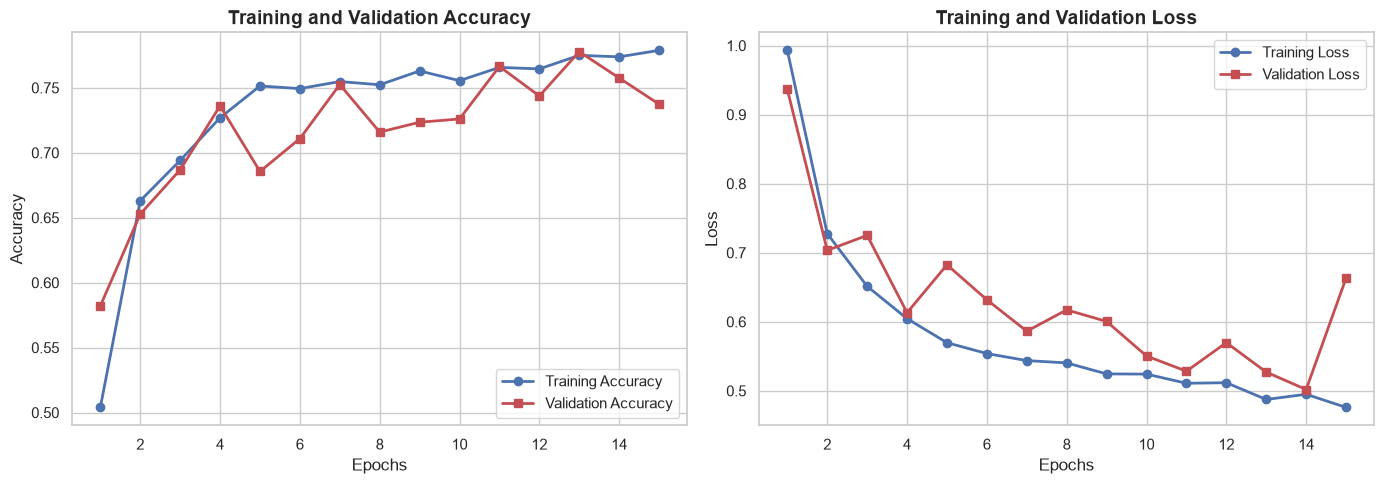

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, 'r-s', label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-o', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, 'r-s', label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# 11. Prediction on New Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


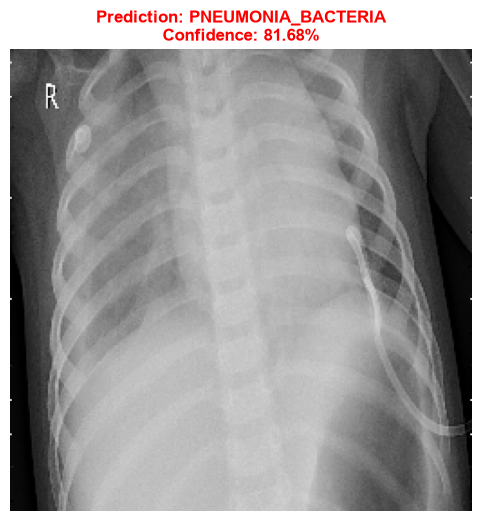

In [12]:
def predict_chest_xray(img_path, class_names=None):
    if class_names is None:
        class_names = ['NORMAL', 'PNEUMONIA_BACTERIA', 'PNEUMONIA_VIRAL']
    
    img = image.load_img(img_path, target_size=(256, 256), color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  
    img_expanded = np.expand_dims(img_array, axis=0)
    
    predictions = model.predict(img_expanded)[0]  
    
    predicted_class_index = np.argmax(predictions)
    label = class_names[predicted_class_index]
    confidence = predictions[predicted_class_index] * 100
    
    color = 'green' if label == 'NORMAL' else 'red'
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img_array.squeeze(), cmap='gray')
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}%", 
              color=color, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

predict_chest_xray('new images/p_ba.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


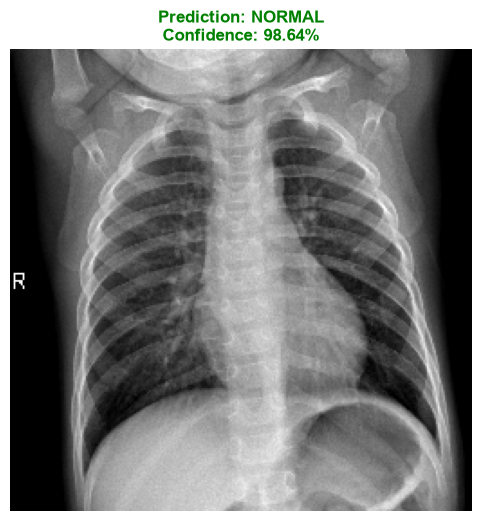

In [11]:
predict_chest_xray('new images/nor.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


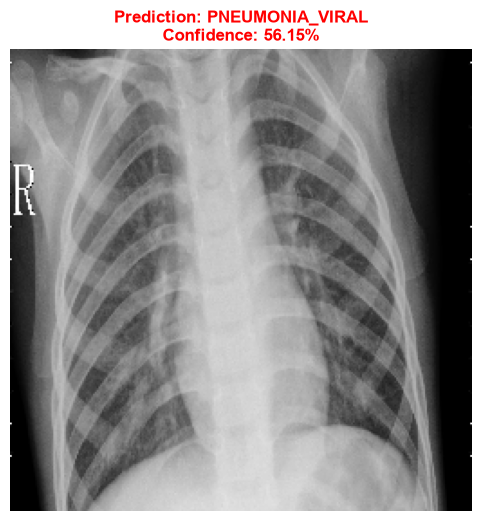

In [10]:
predict_chest_xray('new images/p_vi.jpeg')

# 12. Final Conclusion

In this project, we successfully developed and evaluated a **Deep Learning Convolutional Neural Network (CNN)** pipeline for detecting Pneumonia from chest X-ray images.

Based on the model evaluation, the custom Convolutional Neural Network achieved an overall test accuracy of **85.44%** (Test Loss: `0.5114`) on the 3-class chest X-ray dataset (*NORMAL*, *PNEUMONIA_BACTERIAL*, and *PNEUMONIA_VIRAL*).

---

### 📊 Performance Summary

| Class | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **NORMAL** | **0.96** | 0.79 | 0.87 | 231 |
| **PNEUMONIA_BACTERIAL** | 0.82 | **0.96** | **0.88** | 240 |
| **PNEUMONIA_VIRAL** | 0.78 | 0.78 | 0.78 | 147 |
| **Overall / Macro Avg** | **0.85** | **0.84** | **0.84** | **618** |

---

### 🔑 Key Insights & Findings

* **Exceptional Bacterial Detection:** The model performed exceptionally well in identifying bacterial pneumonia, achieving a high **recall of 0.96** (230 out of 240 samples correctly classified) and an **F1-score of 0.88**.
* **High Precision for Normal Cases:** The model demonstrated strong specificity for normal X-rays, reaching a **precision of 0.96** (183 out of 231 correctly identified as normal).
* **Inter-Class Confusion:** The primary performance bottleneck stems from distinguishing between **PNEUMONIA_VIRAL** and **PNEUMONIA_BACTERIAL**. Specifically, 28 viral pneumonia cases were misclassified as bacterial, and 26 normal cases were misclassified as viral pneumonia.
* **Class Imbalance Handling:** To address the lower support for the `PNEUMONIA_VIRAL` class (147 samples compared to >230 in other classes), **balanced class weights (`class_weight='balanced'`)** were computed and applied during training, alongside **Early Stopping**. This optimization helped maintain a balanced macro-average F1-score of **0.84** and recall of **0.78** for the viral class.

> 💡 **Technical Note:** Incorporating class weights prevented model bias towards majority classes and ensured robust feature learning for the minority viral pneumonia class.

In [ ]:
# model.save('pneumonia_detection_model.keras')

In [ ]:
# import pandas as pd
# import os

# os.makedirs('predictions', exist_ok=True)

# class_names = list(data_test.class_indices.keys())
# true_labels_names = [class_names[i] for i in y_true]
# pred_labels_names = [class_names[i] for i in y_pred]

# results_df = pd.DataFrame({
#     'Filename': data_test.filenames,
#     'True_Label': data_test.classes,
#     'Predicted_Label': pred_labels_names
# })

# results_df.to_csv('predictions/test_predictions.csv', index=False)